# Assignment 2 — Boilerplate vs. Substantive Sentence Classifier
**NLP for Finance — Spring 2026**

| Section | What it does |
|---------|-------------|
| §1 | Environment & paths |
| §2 | Sentence extraction from 131 transcripts |
| §3 | Gold labeling: 7-judge LLM vote + 2-round human audit |
| §4 | Stratified 60/20/20 split |
| §5 | Feature engineering: 384-dim embeddings + 25 regex flags |
| §6 | Classifier zoo: Rules, LogReg, HistGBM, FastText, FinBERT, SetFit |
| §7 | OOF recall-constrained threshold tuning |
| §8 | Ensemble + final test evaluation + leaderboard |
| §9 | Error analysis |


## §1 — Environment & Paths

In [146]:
# Uncomment to install in a fresh environment
# !pip install -q nltk sentence-transformers scikit-learn fasttext-wheel setfit \
#              transformers datasets accelerate pandas numpy pyarrow tqdm matplotlib plotly streamlit

import os, re, json, pickle, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT        = Path('/Users/yueqilin/Desktop/9796 NLP/Transcript Assignment2')
TRANSCRIPTS = ROOT / 'ECT'
CACHE       = ROOT / 'cache'
GOLD_DIR    = CACHE / 'gold'
EMBED_CACHE = CACHE / 'embeddings.pkl'
MODEL_DIR   = ROOT / 'saved_model'

for d in (CACHE, GOLD_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

txts = sorted(TRANSCRIPTS.glob('*.txt'))
print(f'{len(txts)} transcripts found')

131 transcripts found


## §2 — Sentence Extraction

Parse every transcript using the parser used in this Assignment 2 workflow, then sentence-tokenize
with NLTK Punkt. Each sentence is tagged with:
- `ticker`, `quarter`, `call_date`
- `section`: `prepared` or `qa`
- `speaker_type`: `operator`, `ir`, `executive`, `analyst`, `unknown`
- `text`: the sentence itself

Sentences shorter than 40 characters are dropped. Exact duplicates are removed.

In [147]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

# ── Transcript parser for Assignment 2 pipeline ───────────────────────────────
SECTION_HEADERS = {
    'Presentation Operator Message',
    'Presenter Speech',
    'Question and Answer Operator Message',
    'Question',
    'Answer',
}
HEADER_RE = re.compile(
    r'^(?P<company>.+?),\s*Q(?P<q>\d)\s*(?P<y>\d{4}).*?Earnings Call.*?'
    r'(?P<date>[A-Z][a-z]+ \d{1,2},\s*\d{4})'
)

def _blocks(text):
    lines = text.splitlines()
    i, n = 0, len(lines)
    while i < n:
        line = lines[i].strip()
        if line in SECTION_HEADERS:
            section = line; i += 1
            role = lines[i].strip() if i < n else ''; i += 1
            buf = []
            while i < n and lines[i].strip() not in SECTION_HEADERS:
                buf.append(lines[i]); i += 1
            yield section, role, '\n'.join(buf).strip()
        else:
            i += 1

def _speaker_type(role: str) -> str:
    r = role.lower()
    if 'operator' in r:              return 'operator'
    if 'investor relations' in r or r.startswith('executives') and any(
            x in r for x in ['investor', 'ir ', ' ir', 'relations']): return 'ir'
    if r.startswith('executives'):   return 'executive'
    if r.startswith('analysts'):     return 'analyst'
    if r == 'operator':              return 'operator'
    return 'unknown'

def _parse_meta(path):
    text = path.read_text(errors='ignore')
    stem = path.stem
    ticker, _, quarter = stem.partition('_')
    m = HEADER_RE.match(text.splitlines()[0])
    call_date = None
    if m:
        from datetime import datetime
        try:
            call_date = datetime.strptime(m.group('date').replace('  ',' '), '%b %d, %Y').strftime('%Y-%m-%d')
        except ValueError:
            pass
    return ticker, quarter, call_date, text

# ── Sentence extraction ────────────────────────────────────────────────────────
MIN_CHARS = 40

def extract_sentences(path: Path) -> List[Dict]:
    ticker, quarter, call_date, text = _parse_meta(path)
    rows = []
    in_qa = False
    for section, role, body in _blocks(text):
        if section == 'Question and Answer Operator Message':
            in_qa = True; continue
        if not body.strip():
            continue
        sec_label = 'qa' if in_qa else 'prepared'
        spk = _speaker_type(role)
        for sent in sent_tokenize(body):
            sent = sent.strip()
            if len(sent) >= MIN_CHARS:
                rows.append({
                    'ticker': ticker, 'quarter': quarter, 'call_date': call_date,
                    'section': sec_label, 'speaker_type': spk, 'text': sent,
                })
    return rows

# Cache check — skip re-extraction if sentence_pool already saved
_pool_cache = CACHE / 'sentence_pool.parquet'
if _pool_cache.exists():
    sentence_pool = pd.read_parquet(_pool_cache)
    print(f'Loaded sentence_pool from cache: {len(sentence_pool):,} sentences')
    print(sentence_pool['speaker_type'].value_counts().to_string())
else:
    all_rows = []
    for p in tqdm(txts, desc='extracting sentences'):
        all_rows.extend(extract_sentences(p))

    sentence_pool = pd.DataFrame(all_rows)

    # Drop exact duplicates on text
    before = len(sentence_pool)
    sentence_pool = sentence_pool.drop_duplicates(subset='text').reset_index(drop=True)
    print(f'Extracted {before:,} sentences → {len(sentence_pool):,} after dedup')
    print(sentence_pool['speaker_type'].value_counts().to_string())
    print(sentence_pool['section'].value_counts().to_string())

    # Save full pool
    sentence_pool.to_parquet(CACHE / 'sentence_pool.parquet', index=False)
    print('\nSaved sentence_pool.parquet')

Loaded sentence_pool from cache: 53,236 sentences
speaker_type
executive    33133
ir           11988
analyst       7844
operator       271


## §3 — Gold Labeling

**Labeling rubric:**

| Class | Definition | Anchor examples |
|-------|-----------|----------------|
| `boilerplate` (0) | Scripted, generic, no material information | Operator intros, safe-harbor disclaimers, generic thanks, analyst name/firm intros, one-word answers, "please hold", "next question" |
| `substantive` (1) | Material numbers, guidance, strategy, product commentary, risk/opportunity specifics | Revenue figures, margin guidance, segment commentary, specific customer wins, capex plans, analyst questions about financials |

**Edge-case rules:**
- Analyst name intro lines → boilerplate
- "Thank you" + substantive content in same sentence → substantive
- Safe-harbor boilerplate even if it mentions specific metrics → boilerplate
- Short generic affirmations ("Sure.", "Great, thank you.") → boilerplate

**5 judges — majority vote (≥ 3/5):**

| Judge | Model | BP% | Notes |
|-------|-------|-----|-------|
| j3 | cogito:8b | 8.2% | |
| j4 | qwen3:14b | 11.2% | |
| j5 | gemma3:12b | 19.4% | |
| j6 | ministral-3:8b | 16.5% | |
| j7 | cogito:14b | 23.6% | |

**Removed judges (manual review — systematic disagreement with ground truth):**

| Judge | Model | BP% | Reason |
|-------|-------|-----|--------|
| ~~j1~~ | ~~qwen3:8b~~ | ~~29.3%~~ | Over-flagged boilerplate; manual audit disagreed |
| ~~j2~~ | ~~gemma3:4b~~ | ~~47.5%~~ | Severe BP bias; overridden 746/2500 times by majority |

**Human audit (2 rounds):**
- Round 1: 299 close-call sentences reviewed
- Round 2: 216 additional close calls from 7-judge panel (`human_review_round2.csv`)
- Human label overrides LLM majority vote where provided

**Final gold set:** 2,500 sentences | BP = 334 (13.4%) | SB = 2,166 (86.6%)


In [148]:
import requests

OLLAMA_HOST = 'http://localhost:11434'

# ── Sampling: stratified by speaker_type, ~2500 sentences ─────────────────────
GOLD_N = 2500

def stratified_sample(df: pd.DataFrame, n: int, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Sample n rows stratified by speaker_type."""
    rng = np.random.default_rng(seed)
    groups = [g for _, g in df.groupby('speaker_type')]
    weights = np.array([len(g) for g in groups], dtype=float)
    weights /= weights.sum()
    counts = np.round(weights * n).astype(int)
    counts[-1] += n - counts.sum()   # fix rounding
    parts = []
    for g, c in zip(groups, counts):
        parts.append(g.sample(min(c, len(g)), random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

# Recreate gold_sample from the pool (fast, ~2500 rows)
gold_sample = stratified_sample(sentence_pool, GOLD_N)
print(f'Gold sample: {len(gold_sample)} sentences')
print(gold_sample['speaker_type'].value_counts().to_string())

Gold sample: 2500 sentences
speaker_type
executive    1556
ir            563
analyst       368
operator       13


In [149]:
# ── Shared labeling prompt ────────────────────────────────────────────────────
LABEL_PROMPT = '''You are labeling sentences from earnings-call transcripts.

Classify the sentence below as EXACTLY one of:
  boilerplate — scripted, generic, no material information (operator phrases, safe-harbor disclaimers,
                generic thanks, analyst name/firm introductions, housekeeping, "please hold", etc.)
  substantive — material content: financial figures, guidance, segment results, strategy, product
                commentary, specific risks, analyst questions about financials.

Edge cases:
- Analyst name intro lines → boilerplate
- "Thank you" alone or with filler → boilerplate
- Safe-harbor even if it mentions metrics → boilerplate
- Short affirmations ("Sure.", "Great.") → boilerplate
- Sentence with a dollar amount or percentage AND real context → substantive

Respond with ONLY one word: boilerplate or substantive

Sentence: {sentence}'''

def _parse_label(raw: str) -> Optional[int]:
    r = raw.strip().lower()
    if 'boilerplate' in r: return 0
    if 'substantive' in r: return 1
    return None

def ollama_judge(sentence: str, model: str, timeout: int = 45) -> Optional[int]:
    try:
        r = requests.post(f'{OLLAMA_HOST}/api/generate', timeout=timeout, json={
            'model': model,
            'prompt': LABEL_PROMPT.format(sentence=sentence[:500]),
            'stream': False, 'think': False,
            'options': {'think': False, 'num_ctx': 2048, 'temperature': 0.0, 'num_predict': 16},
        })
        r.raise_for_status()
        return _parse_label(r.json()['response'])
    except Exception:
        return None

# ── Connectivity tests (expected: 1 = substantive) ────────────────────────────
_TEST = "Revenue was $26 billion, up 18 percent sequentially."
for _model, _tag in [
    ('cogito:latest',      'j3'),  # cogito:8b
    ('qwen3:14b',          'j4'),
    ('gemma3:12b',         'j5'),
    ('ministral-3:latest', 'j6'),  # ministral-3:8b
    ('cogito:14b',         'j7'),
]:
    _r = ollama_judge(_TEST, _model)
    _s = '✓' if _r == 1 else ('✗' if _r == 0 else '?')
    print(f'  {_s} {_tag} {_model:<22} → {_r}')


  ✓ j3 cogito:latest          → 1
  ✓ j4 qwen3:14b              → 1
  ✓ j5 gemma3:12b             → 1
  ✓ j6 ministral-3:latest     → 1
  ✓ j7 cogito:14b             → 1


In [150]:
# ── §3 Run all 7 LLM judges sequentially ─────────────────────────────────────
# Set FORCE_RELABEL = True to re-run a judge even if its cache exists.
# NOTE: rules_judge is §6 Classifier 1 — not a gold label judge.
#
# Judges:
#   j1 qwen3:8b            (Alibaba Qwen3, 8B)
#   j2 gemma3:4b           (Google Gemma3, 4B)
#   j3 cogito:latest       (Cogito AI, 8B)
#   j4 qwen3:14b           (Alibaba Qwen3, 14B)
#   j5 gemma3:12b          (Google Gemma3, 12B)
#   j6 ministral-3:latest  (Mistral, 8.9B)
#   j7 cogito:14b          (Cogito AI, 14B)
# All 7 run sequentially (shared GPU).
# Checkpoints every 50 sentences — safe to interrupt and resume.

import threading, time
from tqdm.auto import tqdm
from collections import Counter

FORCE_RELABEL    = False
CHECKPOINT_EVERY = 50

# ── Skip if gold already done ─────────────────────────────────────────────────
_gold_done = (GOLD_DIR / 'gold_labels.parquet').exists() and not FORCE_RELABEL
if _gold_done:
    print('gold_labels.parquet exists and FORCE_RELABEL=False — skipping judge run.')
    print('Set FORCE_RELABEL=True to redo.')
    judge_series = {}
else:
    _print_lock = threading.Lock()

    def _log(msg):
        with _print_lock:
            print(msg, flush=True)

    # ── Per-judge runner with checkpointing ───────────────────────────────────
    def _run_judge(texts, judge_fn, name, cache_path):
        ckpt = GOLD_DIR / f'{name}_checkpoint.csv'
        if cache_path.exists() and not FORCE_RELABEL:
            cached = pd.read_parquet(cache_path)
            _log(f'[{name}] cached ({len(cached)} rows, {(cached["label"]==-1).sum()} failures)')
            return cached['label']
        done = {}
        if ckpt.exists() and not FORCE_RELABEL:
            cp = pd.read_csv(ckpt)
            done = dict(zip(cp['text'], cp['label']))
            _log(f'[{name}] resuming from {len(done)} checkpointed rows')
        pending = [(i, t) for i, t in enumerate(texts) if t not in done]
        buf = []
        for _, text in tqdm(pending, desc=f'[{name}]', leave=True):
            lbl = judge_fn(text)
            done[text] = lbl if lbl is not None else -1
            buf.append({'text': text, 'label': done[text]})
            if len(buf) >= CHECKPOINT_EVERY:
                pd.DataFrame(buf).to_csv(ckpt, mode='a',
                    header=not ckpt.exists(), index=False)
                buf = []
        if buf:
            pd.DataFrame(buf).to_csv(ckpt, mode='a',
                header=not ckpt.exists(), index=False)
        final = pd.Series([done[t] for t in texts], name='label')
        pd.DataFrame({'label': final}).to_parquet(cache_path)
        n_fail = (final == -1).sum()
        _log(f'[{name}] DONE — {n_fail}/{len(final)} failures')
        if ckpt.exists(): ckpt.unlink()
        return final

    JUDGES = [
        ('j3_cogito',     lambda t: ollama_judge(t, 'cogito:latest'),      GOLD_DIR/'judge3_cogito.parquet'),
        ('j4_qwen314b',   lambda t: ollama_judge(t, 'qwen3:14b'),          GOLD_DIR/'judge4_qwen314b.parquet'),
        ('j5_gemma12b',   lambda t: ollama_judge(t, 'gemma3:12b'),         GOLD_DIR/'judge5_gemma12b.parquet'),
        ('j6_ministral3', lambda t: ollama_judge(t, 'ministral-3:latest'), GOLD_DIR/'judge6_ministral3.parquet'),
        ('j7_cogito14b',  lambda t: ollama_judge(t, 'cogito:14b'),         GOLD_DIR/'judge7_cogito14b.parquet'),
    ]

    print('Running 5 judges sequentially (shared GPU)...')
    texts = gold_sample['text'].tolist()
    results = {}

    for name, fn, cache in JUDGES:
        t0 = time.time()
        s = _run_judge(texts, fn, name, cache)
        results[name] = s
        _log(f'[{name}] finished in {(time.time()-t0)/60:.1f} min')

    # ── Summary ───────────────────────────────────────────────────────────────
    judge_series = results
    print('\nJudge summary:')
    for name, s in judge_series.items():
        vc = s.value_counts().to_dict()
        print(f'  {name:<16}  BP={vc.get(0,0):4d}  SB={vc.get(1,0):4d}  fail={vc.get(-1,0):4d}')

    # ── Majority vote + save gold_labels.parquet ──────────────────────────────
    gold = gold_sample.copy()
    for name, s in judge_series.items(): gold[name] = s.values
    jnames = list(judge_series.keys())

    def _mv(row):
        votes = [int(row[j]) for j in jnames if row[j] != -1]
        return Counter(votes).most_common(1)[0][0] if votes else -1

    gold['label_mv'] = gold.apply(_mv, axis=1)
    gold = gold[gold['label_mv'] != -1].reset_index(drop=True)

    unanimous = gold[jnames].apply(lambda r: len({r[j] for j in jnames if r[j]!=-1})==1, axis=1)
    print(f'\nGold set: {len(gold)} rows  |  unanimous: {unanimous.mean()*100:.1f}%')
    print(gold['label_mv'].value_counts().rename({0:'boilerplate',1:'substantive'}).to_string())

    keep = ['ticker','quarter','call_date','section','speaker_type','text','label_mv'] + jnames
    out  = gold[keep].rename(columns={'label_mv':'label'})
    out.to_parquet(GOLD_DIR / 'gold_labels.parquet', index=False)
    print(f'\nSaved gold_labels.parquet ({len(out)} rows)')


gold_labels.parquet exists and FORCE_RELABEL=False — skipping judge run.
Set FORCE_RELABEL=True to redo.


### Human Pass (2 rounds)

**Round 1** (complete — 299 labels in `human_review.csv`)

**Round 2** (current — 216 labels in `human_review_round2.csv`)

**Workflow:**

**Step 1 — Run the export cell below** to regenerate close-call CSVs from the 7-judge panel.

**Step 2 — Open `cache/gold/human_review_round2.csv`**, fill the `human_label` column (0 = boilerplate, 1 = substantive), save.

**Step 3 — Run the import cell** to merge both rounds. Human labels override the LLM majority vote.


In [151]:
# ── STEP 1: Export close calls for human review ──────────────────────────────
# Reads the current gold_labels.parquet (5 active judges j3–j7), finds
# 2-3 / 3-2 splits not yet human-labeled, and exports them sorted tightest-split-first.
# NOTE: j1 (qwen3:8b) and j2 (gemma3:4b) were removed for systematic bias;
#       gold_labels.parquet only contains the 5 active judges.

import pandas as pd
from pathlib import Path

_gold = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')
_judge_cols = ['j3_cogito','j4_qwen314b','j5_gemma12b','j6_ministral3','j7_cogito14b']

# j_human column is added by the import cell (Step 2) — default to -1 if not yet present
if 'j_human' not in _gold.columns:
    _gold['j_human'] = -1

_gold['n_bp'] = _gold[_judge_cols].apply(lambda r: sum(1 for v in r if v == 0), axis=1)
_gold['n_sb'] = _gold[_judge_cols].apply(lambda r: sum(1 for v in r if v == 1), axis=1)

close = _gold[_gold['n_bp'].isin([2, 3])].copy()
new_close = close[close['j_human'] == -1].copy()
new_close['sort_key'] = new_close['n_bp'].apply(lambda x: abs(x - 2.5))
new_close = new_close.sort_values(['sort_key', 'speaker_type'])

out = new_close[['text','speaker_type','section'] + _judge_cols + ['n_bp','n_sb','label']].copy()
out = out.rename(columns={'label': 'llm_mv'})
out['human_label'] = ''

HUMAN_CSV2 = GOLD_DIR / 'human_review_round2.csv'
out.to_csv(HUMAN_CSV2, index=False)
print(f'Exported {len(out)} sentences → {HUMAN_CSV2}')
print(f'  3 BP / 2 SB: {(new_close.n_bp==3).sum()}  (tightest)')
print(f'  2 BP / 3 SB: {(new_close.n_bp==2).sum()}')
print(f'
Fill human_label column (0=BP, 1=SB), then run the import cell.')

SyntaxError: unterminated string literal (detected at line 34) (437144437.py, line 34)

In [ ]:
# ── STEP 2: Import human labels from both rounds + recompute gold ─────────────
# Human label overrides the LLM majority vote where provided.
# Round 2 takes precedence on any overlap with round 1.

HUMAN_CSV1 = GOLD_DIR / 'human_review.csv'
HUMAN_CSV2 = GOLD_DIR / 'human_review_round2.csv'

def _load_csv_labels(path):
    if not Path(path).exists():
        return {}
    df = pd.read_csv(path)
    label_map = {}
    for _, row in df.iterrows():
        val = str(row.get('human_label', '')).strip()
        if val in ('0', '1', '0.0', '1.0'):
            label_map[row['text']] = int(float(val))
    return label_map

r1 = _load_csv_labels(HUMAN_CSV1)
r2 = _load_csv_labels(HUMAN_CSV2)
human_map = {**r1, **r2}   # round 2 overwrites round 1 on overlap
print(f'Human labels: round1={len(r1)}  round2={len(r2)}  combined={len(human_map)}')
print(f'  BP={sum(1 for v in human_map.values() if v==0)}  '
      f'SB={sum(1 for v in human_map.values() if v==1)}')

gold_final   = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')
orig_labels  = gold_final['label'].copy()   # snapshot before override

gold_final['j_human'] = gold_final['text'].map(human_map).fillna(-1).astype(int)
gold_final['label']   = gold_final.apply(
    lambda r: r['j_human'] if r['j_human'] != -1 else r['label'], axis=1
)

n_overridden = (gold_final['j_human'] != -1).sum()
n_flipped    = ((gold_final['j_human'] != -1) & (gold_final['j_human'] != orig_labels)).sum()
bp = (gold_final['label'] == 0).sum()
sb = (gold_final['label'] == 1).sum()
print(f'\nGold set: {len(gold_final)} rows  '
      f'BP={bp} ({bp/len(gold_final)*100:.1f}%)  SB={sb} ({sb/len(gold_final)*100:.1f}%)')
print(f'Human overrides applied: {n_overridden}  ({n_flipped} changed the LLM label)')

gold_final.to_parquet(GOLD_DIR / 'gold_labels.parquet', index=False)
print('Saved gold_labels.parquet')


Human labels: round1=316  round2=0  combined=316
  BP=20  SB=296

Gold set: 2500 rows  BP=262 (10.5%)  SB=2238 (89.5%)
Human overrides applied: 316  (0 changed the LLM label)
Saved gold_labels.parquet


In [ ]:
# ── Load finalized gold set for downstream sections ──────────────────────────
# gold_labels.parquet is written by the import cell above (or directly by
# run_gold_judges.py). This cell just confirms it exists and prints stats.

gold_final = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')
print(f'gold_labels.parquet loaded: {len(gold_final)} rows')
print(gold_final['label'].value_counts().rename({0:'boilerplate', 1:'substantive'}).to_string())
judge_cols_all = [c for c in gold_final.columns if c.startswith('j') and c[1:2].isdigit()]
print(f'Judge columns: {judge_cols_all}')


gold_labels.parquet loaded: 2500 rows
label
substantive    2238
boilerplate     262
Judge columns: ['j3_cogito', 'j4_qwen314b', 'j5_gemma12b', 'j6_ministral3', 'j7_cogito14b']


## §4 — Stratified Train / Val / Test Split

60% train / 20% val / 20% test, stratified by label. Test split is **frozen** — not touched until the final evaluation run.

In [ ]:
from sklearn.model_selection import train_test_split

gold_final = pd.read_parquet(GOLD_DIR / 'gold_labels.parquet')

X_all = gold_final['text'].values
y_all = gold_final['label'].values

# 60 / 20 / 20
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=RANDOM_SEED)  # 0.25 × 0.80 = 0.20

print(f'train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}')
for split_name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    bp = (y == 0).sum(); sb = (y == 1).sum()
    print(f'  {split_name}: boilerplate={bp} ({bp/len(y)*100:.1f}%)  substantive={sb} ({sb/len(y)*100:.1f}%)')

# Save splits (indices into gold_final)
splits = {'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
          'y_train': y_train, 'y_val': y_val, 'y_test': y_test}
with open(CACHE / 'splits.pkl', 'wb') as f:
    pickle.dump(splits, f)
print('Saved splits.pkl')

train: 1500  val: 500  test: 500
  train: boilerplate=157 (10.5%)  substantive=1343 (89.5%)
  val: boilerplate=53 (10.6%)  substantive=447 (89.4%)
  test: boilerplate=52 (10.4%)  substantive=448 (89.6%)
Saved splits.pkl


## §5 — Feature Engineering

Two feature groups, concatenated:

1. **25 regex flags** — binary indicators for boilerplate/substantive signals  
2. **Sentence embeddings** — `all-MiniLM-L6-v2` (384-dim), cached to disk

The combined feature matrix is what every classifier (except FastText and FinBERT) trains on.

In [ ]:
# ── 25 regex feature flags ────────────────────────────────────────────────────

REGEX_FEATURES = [
    # --- Boilerplate signals ---
    ('f_operator_phrase',   r'(?i)(my name is|conference operator|welcome everyone|welcome to nvidia|welcome to the)'),
    ('f_safe_harbor',       r'(?i)(forward[- ]looking|safe[- ]harbor|actual results may differ|risks and uncertainties)'),
    ('f_sec_filing',        r'(?i)(form 10-[kq]|sec filing|securities and exchange|8-k|annual report)'),
    ('f_webcast',           r'(?i)(webcast|replay until|investor relations website|ir website)'),
    ('f_generic_thanks',    r'(?i)\b(thank you|thanks)\b(?!.{0,30}(revenue|guidance|earnings|results|growth))'),
    ('f_question_intro',    r'(?i)(our next question|your line is (open|now)|goes to the line of|you may (begin|proceed|go ahead))'),
    ('f_analyst_firm',      r'(?i)\b(Goldman|Morgan Stanley|JPMorgan|Citi(group)?|UBS|Wells Fargo|Deutsche Bank|Barclays|BofA|Bernstein|Cowen|Jefferies|Piper Sandler|Evercore|Oppenheimer|Mizuho)\b'),
    ('f_call_close',        r'(?i)(no further questions|this concludes|thank you for (your time|participating|joining))'),
    ('f_nongaap',           r'(?i)(non-gaap|reconciliation|gaap (to|and) non-gaap)'),
    ('f_short_affirm',      r'(?i)^(sure\.?|great\.?|okay\.?|yes\.?|absolutely\.?|of course\.?|thank you\.?)\s*$'),
    ('f_operator_instr',    r'(?i)\[operator instructions\]'),
    ('f_turn_over',         r'(?i)(turn (the call|it) over|let me (now )?turn|i.d like to (now )?turn)'),
    # --- Substantive signals ---
    ('f_dollar_amount',     r'\$[\d,\.]+\s*(billion|million|thousand|[BbMmKk])?'),
    ('f_percentage',        r'\b\d+(\.\d+)?\s*%'),
    ('f_revenue_mention',   r'(?i)\b(revenue|net (income|loss|sales)|total (sales|revenue))\b'),
    ('f_margin_mention',    r'(?i)\b(gross margin|operating margin|ebitda margin|profit margin)\b'),
    ('f_eps_mention',       r'(?i)\b(earnings per share|eps|diluted eps|non-gaap eps)\b'),
    ('f_guidance_word',     r'(?i)\b(guidance|outlook|forecast|expect(s|ed)?|anticipate[sd]?|project(s|ed)?|full[- ]year)\b'),
    ('f_raised_lowered',    r'(?i)\b(raised?|lowered?|increased?|decreased?|reaffirmed?)\s+(guidance|outlook|revenue|earnings|estimate)'),
    ('f_yoy_qoq',           r'(?i)\b(year[- ]over[- ]year|sequentially|quarter[- ]over[- ]quarter|yoy|qoq|vs\. prior)\b'),
    ('f_record_quarter',    r'(?i)\b(record (revenue|quarter|sales|profit|high)|all[- ]time (high|record))\b'),
    ('f_product_launch',    r'(?i)\b(launched?|announced?|introduced?|released?|shipped?|ramped?)\s+(new |our |the )?\w+ (platform|product|system|service|model|chip|GPU|CPU)'),
    ('f_customer_mention',  r'(?i)\b(customer(s)?|client(s)?|partner(s)?)\s+(include|such as|like|across|with)'),
    # --- Structural signals ---
    ('f_sentence_short',    None),   # computed below (len < 10 words)
    ('f_has_digits',        r'\b\d+\b'),
]

COMPILED = [(name, re.compile(pat) if pat else None) for name, pat in REGEX_FEATURES]

def build_regex_features(texts):
    rows = []
    for text in texts:
        row = []
        for name, pattern in COMPILED:
            if name == 'f_sentence_short':
                row.append(1 if len(text.split()) < 10 else 0)
            else:
                row.append(1 if pattern.search(text) else 0)
        rows.append(row)
    return np.array(rows, dtype=np.float32)

feat_names = [name for name, _ in REGEX_FEATURES]
print(f'{len(feat_names)} regex features defined')

# Quick sanity
sample_texts = [
    "Revenue of $26 billion was up 18% sequentially.",
    "My name is Regina and I will be your conference operator.",
]
sample_feats = build_regex_features(sample_texts)
for t, feats in zip(sample_texts, sample_feats):
    active = [feat_names[i] for i, v in enumerate(feats) if v > 0]
    print(f'  "{t[:60]}"')
    print(f'    → {active}')

25 regex features defined
  "Revenue of $26 billion was up 18% sequentially."
    → ['f_dollar_amount', 'f_percentage', 'f_revenue_mention', 'f_yoy_qoq', 'f_sentence_short', 'f_has_digits']
  "My name is Regina and I will be your conference operator."
    → ['f_operator_phrase']


In [ ]:
# ── Sentence embeddings (cached) ──────────────────────────────────────────────
# Uses all-MiniLM-L6-v2 (384-dim). Runs on Apple MPS if available.

from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

def get_embeddings(texts, model_name=EMBED_MODEL_NAME, batch_size=256, cache_key='all'):
    """Embed texts, using disk cache keyed by cache_key."""
    cache = CACHE / f'embeddings_{cache_key}.pkl'
    if cache.exists():
        with open(cache, 'rb') as f:
            data = pickle.load(f)
        if data.get('model') == model_name and data.get('n') == len(texts):
            print(f'  Embeddings loaded from cache ({cache_key}): {data["emb"].shape}')
            return data['emb']
    print(f'  Embedding {len(texts)} sentences with {model_name}...')
    model = SentenceTransformer(model_name)
    emb = model.encode(list(texts), batch_size=batch_size, show_progress_bar=True,
                       convert_to_numpy=True, normalize_embeddings=True)
    with open(cache, 'wb') as f:
        pickle.dump({'model': model_name, 'n': len(texts), 'emb': emb}, f)
    print(f'  Saved embeddings cache: {emb.shape}')
    return emb

# Embed all gold sentences at once, then split by index
all_texts = gold_final['text'].values
all_emb = get_embeddings(all_texts, cache_key='gold')

# Recover split indices
with open(CACHE / 'splits.pkl', 'rb') as f:
    splits = pickle.load(f)

# We need to match texts back to indices in gold_final
text_to_idx = {t: i for i, t in enumerate(all_texts)}

def texts_to_emb(texts):
    idxs = [text_to_idx[t] for t in texts]
    return all_emb[idxs]

# Build feature matrices
def build_full_features(texts):
    emb = texts_to_emb(texts)
    reg = build_regex_features(texts)
    return np.hstack([emb, reg])

print('\nBuilding feature matrices...')
F_train = build_full_features(splits['X_train'])
F_val   = build_full_features(splits['X_val'])
F_test  = build_full_features(splits['X_test'])
print(f'Feature dimensions: train={F_train.shape}  val={F_val.shape}  test={F_test.shape}')

y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']

  Embeddings loaded from cache (gold): (2500, 384)

Building feature matrices...
Feature dimensions: train=(1500, 409)  val=(500, 409)  test=(500, 409)


## §6 — Classifier Zoo

Seven classifiers trained on identical features/splits. Timings measured on M1.

| # | Family | Feature input |
|---|--------|---------------|
| 1 | Rules + regex | regex flags only |
| 2 | LogReg on embeddings | embeddings + regex |
| 3 | HistGBM | embeddings + regex |
| 4 | FastText | raw text |
| 5 | FinBERT fine-tuned | raw text (MPS) |
| 6 | SetFit | raw text (MPS) |
| 7 | Ensemble | mean-prob of best 5 |

In [ ]:
# ── Classifier 1 helper: Rules-based classifier ──────────────────────────────
# NOTE: (?i) inline flags stripped; re.IGNORECASE used instead
# (joining with | breaks inline flags in Python 3.11+).

_BP_PATTERNS = [
    r'\b(good\s+(morning|afternoon|evening)|welcome\s+to|thank\s+you\s+for\s+(joining|calling|participating))\b',
    r'\b(my\s+name\s+is|i\s+will\s+be\s+your\s+(conference\s+)?operator)\b',
    r'\b(forward[- ]looking\s+statement|safe[- ]harbor|actual\s+results\s+may\s+differ)\b',
    r'\b(please\s+(press|hold|stand\s+by)|operator\s+instructions)\b',
    r'(\[operator\s+instructions\])',
    r'\b(our\s+next\s+question|your\s+line\s+is\s+(open|now\s+open)|goes\s+to\s+(the\s+line\s+of|[A-Z]))\b',
    r'\b(you\s+may\s+(begin|proceed|go\s+ahead))\b',
    r'\b(no\s+further\s+questions|this\s+concludes\s+today.s\s+(call|conference|question)|thank\s+you\s+for\s+your\s+(time|participation|attending))\b',
    r'\b(webcast\s+(will\s+be\s+)?available|replay\s+until|investor\s+relations\s+website)\b',
    r'\b(non[-\s]gaap|reconciliation|sec\s+filings|form\s+10-[kq]|securities\s+and\s+exchange)\b',
    r'^(sure\.?|great\.?|okay\.?|yes\.?|absolutely\.?|of\s+course\.?)\s*$',
    r'\b(i\s+would\s+like\s+to\s+(introduce|turn\s+the\s+call\s+over|welcome))\b',
    r'\b(from\s+the\s+line\s+of|with\s+(Goldman|Morgan|JPMorgan|Citi|UBS|Wells|Deutsche|Barclays|BofA|Bank\s+of\s+America|Bernstein|Cowen|Raymond|Jefferies|Piper|Evercore|Oppenheimer|Mizuho))\b',
]
_BP_RE = re.compile('|'.join(_BP_PATTERNS), re.IGNORECASE)

_SUBST_PATTERNS = [
    r'\$[\d,\.]+\s*(billion|million|thousand|b|m)?',
    r'\b\d+(\.\d+)?\s*%',
    r'\b(revenue|eps|earnings\s+per\s+share|gross\s+margin|operating\s+(income|margin)|net\s+(income|loss)|ebitda|guidance|outlook|forecast)\b',
    r'\b(year[- ]over[- ]year|sequentially|quarter[- ]over[- ]quarter|yoy|qoq)\b',
    r'\b(raised?|lowered?|reaffirmed?|expect(s|ed)?|anticipate[sd]?)\s+(guidance|outlook|revenue|earnings)\b',
    r'\b(record\s+(revenue|quarter|sales|profit)|all[- ]time\s+high)\b',
]
_SUBST_RE = re.compile('|'.join(_SUBST_PATTERNS), re.IGNORECASE)

def rules_judge(text: str) -> int:
    """Returns 0 (boilerplate) or 1 (substantive)."""
    if _BP_RE.search(text):
        # Override if strong substantive signal also present
        if _SUBST_RE.search(text) and len(text) > 80:
            return 1
        return 0
    if _SUBST_RE.search(text):
        return 1
    # Short sentences with no signal → boilerplate
    if len(text.split()) < 12:
        return 0
    return 1  # default: substantive for longer sentences without BP markers

# Test rules judge
test_cases = [
    ("My name is Regina and I will be your conference operator today.", 0),
    ("Revenue of $26 billion was up 18% sequentially and up 262% year-on-year.", 1),
    ("These are subject to a number of significant risks and uncertainties.", 0),
    ("We expect full-year revenue growth of approximately 15% to 20%.", 1),
    ("Thank you.", 0),
    ("Your line is open.", 0),
]
print('Rules judge sanity check:')
all_pass = True
for text, expected in test_cases:
    pred = rules_judge(text)
    status = '✓' if pred == expected else '✗'
    if pred != expected: all_pass = False
    print(f'  {status} [{"BP" if pred==0 else "SB"}] {text[:70]}')
print('All pass!' if all_pass else 'Some mismatches — review patterns.')


Rules judge sanity check:
  ✓ [BP] My name is Regina and I will be your conference operator today.
  ✓ [SB] Revenue of $26 billion was up 18% sequentially and up 262% year-on-yea
  ✓ [BP] These are subject to a number of significant risks and uncertainties.
  ✓ [SB] We expect full-year revenue growth of approximately 15% to 20%.
  ✓ [BP] Thank you.
  ✓ [BP] Your line is open.
All pass!


In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, roc_auc_score
)
import time

SUBSTANTIVE_CLASS = 1
RECALL_FLOOR = 0.96

leaderboard = []

def evaluate(name, y_true, y_pred, y_proba=None, train_time=None, infer_time=None, n_infer=None):
    acc    = (y_true == y_pred).mean()
    mf1    = f1_score(y_true, y_pred, average='macro')
    bp_f1  = f1_score(y_true, y_pred, pos_label=0)
    sb_f1  = f1_score(y_true, y_pred, pos_label=1)
    rep    = classification_report(y_true, y_pred,
                                   target_names=['boilerplate','substantive'], digits=3)
    cm     = confusion_matrix(y_true, y_pred)
    sb_rec = cm[1,1] / max(1, cm[1,:].sum())
    throughput = (n_infer / infer_time) if (infer_time and n_infer) else None
    row = {
        'model': name, 'accuracy': acc, 'macro_f1': mf1,
        'bp_f1': bp_f1, 'sb_f1': sb_f1, 'sb_recall': sb_rec,
        'meets_floor': sb_rec >= RECALL_FLOOR,
        'train_sec': train_time, 'throughput_sps': throughput,
    }
    leaderboard.append(row)
    print(f'\n=== {name} ===')
    print(rep)
    print(f'Confusion matrix:\n{cm}')
    if train_time  is not None: print(f'Train time: {train_time:.1f}s')
    if throughput  is not None: print(f'Throughput: {throughput:.0f} sentences/sec')
    return row

def threshold_sweep(y_true, probas_subst, recall_floor=RECALL_FLOOR):
    """
    Sweep thresholds [0.01, 0.99].
    Primary: highest macro-F1 subject to substantive recall >= recall_floor.
    Fallback (floor unachievable): threshold with highest substantive recall,
    then highest macro-F1 among ties. Always returns a float, never None.
    """
    thresholds = np.linspace(0.01, 0.99, 197)
    best_t, best_f1 = None, -1
    # fallback tracking
    fb_t, fb_rec, fb_f1 = thresholds[0], -1.0, -1.0

    for t in thresholds:
        preds = (probas_subst >= t).astype(int)
        if preds.sum() == 0:
            continue
        sb_rec = ((preds == 1) & (y_true == 1)).sum() / max(1, (y_true == 1).sum())
        mf1    = f1_score(y_true, preds, average='macro')
        # primary
        if sb_rec >= recall_floor and mf1 > best_f1:
            best_f1, best_t = mf1, t
        # fallback: prefer highest recall, break ties with macro-F1
        if sb_rec > fb_rec or (sb_rec == fb_rec and mf1 > fb_f1):
            fb_rec, fb_f1, fb_t = sb_rec, mf1, t

    if best_t is None:
        print(f'  WARNING: no threshold achieves recall >= {recall_floor:.2f}. '
              f'Falling back to best-recall threshold {fb_t:.3f} '
              f'(recall={fb_rec:.3f}, macro-F1={fb_f1:.3f}).')
        return fb_t, fb_f1
    return best_t, best_f1

def apply_threshold(probas, threshold):
    return (probas >= threshold).astype(int)

print('Evaluation helpers ready.')


Evaluation helpers ready.


In [ ]:
# ── Classifier 1: Rules + regex ───────────────────────────────────────────────

t0 = time.time()
y_pred_rules = np.array([rules_judge(t) for t in X_val])
infer_time = time.time() - t0

evaluate('1-Rules+Regex', y_val, y_pred_rules,
         train_time=0, infer_time=infer_time, n_infer=len(X_val))


=== 1-Rules+Regex ===
              precision    recall  f1-score   support

 boilerplate      0.375     0.509     0.432        53
 substantive      0.939     0.899     0.919       447

    accuracy                          0.858       500
   macro avg      0.657     0.704     0.675       500
weighted avg      0.879     0.858     0.867       500

Confusion matrix:
[[ 27  26]
 [ 45 402]]
Train time: 0.0s
Throughput: 25627 sentences/sec


{'model': '1-Rules+Regex',
 'accuracy': 0.858,
 'macro_f1': 0.6754285714285715,
 'bp_f1': 0.432,
 'sb_f1': 0.9188571428571429,
 'sb_recall': 0.8993288590604027,
 'meets_floor': False,
 'train_sec': 0,
 'throughput_sps': 25626.590089814872}

In [152]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

t0 = time.time()
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED,
                               class_weight='balanced')),
])
lr_pipe.fit(F_train, y_train)
train_time = time.time() - t0

t0 = time.time()
y_pred_lr = lr_pipe.predict(F_val)
proba_lr  = lr_pipe.predict_proba(F_val)[:, 1]
infer_time = time.time() - t0

# Diagnostic: probability distribution
print(f'P(substantive) stats — min={proba_lr.min():.3f}  max={proba_lr.max():.3f}  '
      f'mean={proba_lr.mean():.3f}  median={np.median(proba_lr):.3f}')

best_t_lr, best_f1_lr = threshold_sweep(y_val, proba_lr)
y_pred_lr_t = apply_threshold(proba_lr, best_t_lr)
print(f'LogReg best threshold: {best_t_lr:.3f}  (macro-F1={best_f1_lr:.4f})')

evaluate('2-LogReg(emb+regex)', y_val, y_pred_lr_t, proba_lr,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


P(substantive) stats — min=0.000  max=1.000  mean=0.898  median=1.000
LogReg best threshold: 0.155  (macro-F1=0.7965)

=== 2-LogReg(emb+regex) ===
              precision    recall  f1-score   support

 boilerplate      0.744     0.547     0.630        53
 substantive      0.948     0.978     0.963       447

    accuracy                          0.932       500
   macro avg      0.846     0.762     0.796       500
weighted avg      0.926     0.932     0.927       500

Confusion matrix:
[[ 29  24]
 [ 10 437]]
Train time: 0.3s
Throughput: 58637 sentences/sec


{'model': '2-LogReg(emb+regex)',
 'accuracy': 0.932,
 'macro_f1': 0.7964949243439954,
 'bp_f1': 0.6304347826086957,
 'sb_f1': 0.9625550660792952,
 'sb_recall': 0.9776286353467561,
 'meets_floor': True,
 'train_sec': 0.26433897018432617,
 'throughput_sps': 58636.99147210961}

In [153]:
from sklearn.ensemble import HistGradientBoostingClassifier

t0 = time.time()
gbm = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=6,
    min_samples_leaf=20, random_state=RANDOM_SEED,
    class_weight='balanced',
)
gbm.fit(F_train, y_train)
train_time = time.time() - t0

t0 = time.time()
proba_gbm  = gbm.predict_proba(F_val)[:, 1]
infer_time = time.time() - t0

print(f'P(substantive) stats — min={proba_gbm.min():.3f}  max={proba_gbm.max():.3f}  '
      f'mean={proba_gbm.mean():.3f}  median={np.median(proba_gbm):.3f}')

best_t_gbm, best_f1_gbm = threshold_sweep(y_val, proba_gbm)
y_pred_gbm_t = apply_threshold(proba_gbm, best_t_gbm)
print(f'HistGBM best threshold: {best_t_gbm:.3f}  (macro-F1={best_f1_gbm:.4f})')

evaluate('3-HistGBM(emb+regex)', y_val, y_pred_gbm_t, proba_gbm,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


P(substantive) stats — min=0.000  max=1.000  mean=0.945  median=1.000
HistGBM best threshold: 0.955  (macro-F1=0.8273)

=== 3-HistGBM(emb+regex) ===
              precision    recall  f1-score   support

 boilerplate      0.685     0.698     0.692        53
 substantive      0.964     0.962     0.963       447

    accuracy                          0.934       500
   macro avg      0.825     0.830     0.827       500
weighted avg      0.935     0.934     0.934       500

Confusion matrix:
[[ 37  16]
 [ 17 430]]
Train time: 3.2s
Throughput: 33866 sentences/sec


{'model': '3-HistGBM(emb+regex)',
 'accuracy': 0.934,
 'macro_f1': 0.8273173488503521,
 'bp_f1': 0.6915887850467289,
 'sb_f1': 0.9630459126539753,
 'sb_recall': 0.9619686800894854,
 'meets_floor': True,
 'train_sec': 3.22236704826355,
 'throughput_sps': 33865.99919257166}

In [154]:
import subprocess, sys, tempfile

try:
    import fasttext
except ModuleNotFoundError:
    print('Installing fasttext-wheel...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'fasttext-wheel'])
    import fasttext
    print('fasttext installed.')

def write_fasttext_data(texts, labels, path):
    with open(path, 'w', encoding='utf-8') as f:
        for t, l in zip(texts, labels):
            clean = t.replace('\n', ' ').strip()
            f.write(f'__label__{l} {clean}\n')

with tempfile.TemporaryDirectory() as tmpdir:
    train_file = os.path.join(tmpdir, 'train.txt')
    write_fasttext_data(X_train, y_train, train_file)

    t0 = time.time()
    ft_model = fasttext.train_supervised(
        input=train_file,
        epoch=25, lr=0.5, wordNgrams=2, dim=100, minCount=2,
        loss='softmax', verbose=0,
    )
    train_time = time.time() - t0

t0 = time.time()
ft_preds_raw = ft_model.predict([t.replace('\n', ' ') for t in X_val])
infer_time   = time.time() - t0

ft_probas = np.array([
    (p[0] if l[0] == '__label__1' else 1 - p[0])
    for l, p in zip(ft_preds_raw[0], ft_preds_raw[1])
])

print(f'P(substantive) stats — min={ft_probas.min():.3f}  max={ft_probas.max():.3f}  '
      f'mean={ft_probas.mean():.3f}  median={np.median(ft_probas):.3f}')

best_t_ft, best_f1_ft = threshold_sweep(y_val, ft_probas)
y_pred_ft_t = apply_threshold(ft_probas, best_t_ft)
print(f'FastText best threshold: {best_t_ft:.3f}  (macro-F1={best_f1_ft:.4f})')

evaluate('4-FastText', y_val, y_pred_ft_t, ft_probas,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))

ft_model.save_model(str(MODEL_DIR / 'fasttext_model.bin'))
print('FastText model saved.')


P(substantive) stats — min=0.000  max=1.000  mean=0.965  median=1.000
FastText best threshold: 0.930  (macro-F1=0.7074)

=== 4-FastText ===
              precision    recall  f1-score   support

 boilerplate      0.606     0.377     0.465        53
 substantive      0.929     0.971     0.950       447

    accuracy                          0.908       500
   macro avg      0.768     0.674     0.707       500
weighted avg      0.895     0.908     0.898       500

Confusion matrix:
[[ 20  33]
 [ 13 434]]
Train time: 0.5s
Throughput: 49564 sentences/sec
FastText model saved.


In [155]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

FINBERT_MODEL = 'ProsusAI/finbert'
FINBERT_DIR   = MODEL_DIR / 'finbert_finetuned'

device = 'cpu'  # MPS OOMs on M1 Pro with FinBERT + other models in memory
print(f'Device: {device}')

tokenizer_fb = AutoTokenizer.from_pretrained(FINBERT_MODEL)

def finbert_predict(texts):
    """Direct PyTorch batch inference — no Trainer or accelerate dependency."""
    model_fb.eval()
    all_logits = []
    with torch.no_grad():
        for i in range(0, len(texts), 32):
            enc = tokenizer_fb(
                list(texts[i:i+32]), truncation=True, max_length=128,
                padding=True, return_tensors='pt')
            enc = {k: v.to(device) for k, v in enc.items()}
            all_logits.append(model_fb(**enc).logits.cpu())
    return torch.softmax(torch.cat(all_logits), dim=-1).numpy()[:, 1]

_fb_cached = (FINBERT_DIR / 'config.json').exists()
if _fb_cached:
    print('FinBERT: loading saved model from cache...')
    model_fb = AutoModelForSequenceClassification.from_pretrained(str(FINBERT_DIR))
    model_fb.to(device)
    train_time = 0.0
else:
    # Only import Trainer when we actually need to train from scratch
    from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
    from datasets import Dataset as HFDataset

    def _make_hf_ds(texts, labels):
        return HFDataset.from_dict({'text': list(texts), 'label': list(labels.astype(int))})

    def _tokenize(batch):
        return tokenizer_fb(batch['text'], truncation=True, max_length=128)

    collator = DataCollatorWithPadding(tokenizer_fb)
    ds_train_fb = _make_hf_ds(X_train, y_train).map(_tokenize, batched=True)
    ds_val_fb   = _make_hf_ds(X_val,   y_val  ).map(_tokenize, batched=True)

    model_fb = AutoModelForSequenceClassification.from_pretrained(
        FINBERT_MODEL, num_labels=2, ignore_mismatched_sizes=True)
    model_fb.to(device)

    training_args = TrainingArguments(
        output_dir=str(FINBERT_DIR),
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        logging_steps=50,
        report_to='none',
        dataloader_num_workers=0,
    )
    trainer = Trainer(
        model=model_fb, args=training_args,
        train_dataset=ds_train_fb, eval_dataset=ds_val_fb,
        data_collator=collator,
    )
    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0
    print(f'FinBERT fine-tuning done in {train_time/60:.1f} min')
    trainer.save_model(str(FINBERT_DIR))
    print('FinBERT model saved.')

t0 = time.time()
proba_fb = finbert_predict(X_val)
infer_time = time.time() - t0

print(f'P(substantive) stats — min={proba_fb.min():.3f}  max={proba_fb.max():.3f}  '
      f'mean={proba_fb.mean():.3f}  median={np.median(proba_fb):.3f}')

best_t_fb, best_f1_fb = threshold_sweep(y_val, proba_fb)
y_pred_fb_t = apply_threshold(proba_fb, best_t_fb)
print(f'FinBERT best threshold: {best_t_fb:.3f}  (macro-F1={best_f1_fb:.4f})')

evaluate('5-FinBERT-FT', y_val, y_pred_fb_t, proba_fb,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


Device: cpu
FinBERT: loading saved model from cache...
P(substantive) stats — min=0.021  max=0.997  mean=0.913  median=0.995
FinBERT best threshold: 0.795  (macro-F1=0.9064)

=== 5-FinBERT-FT ===
              precision    recall  f1-score   support

 boilerplate      0.875     0.792     0.832        53
 substantive      0.976     0.987     0.981       447

    accuracy                          0.966       500
   macro avg      0.925     0.890     0.906       500
weighted avg      0.965     0.966     0.965       500

Confusion matrix:
[[ 42  11]
 [  6 441]]
Train time: 0.0s
Throughput: 69 sentences/sec


{'model': '5-FinBERT-FT',
 'accuracy': 0.966,
 'macro_f1': 0.9063866342140332,
 'bp_f1': 0.8316831683168316,
 'sb_f1': 0.9810901001112348,
 'sb_recall': 0.9865771812080537,
 'meets_floor': True,
 'train_sec': 0.0,
 'throughput_sps': 69.35600522754909}

In [156]:
import sys
import numpy as np
from sklearn.linear_model import LogisticRegression

SETFIT_DIR = MODEL_DIR / 'setfit_model'
_sf_loaded = False

# ── Attempt: load fine-tuned checkpoint via setfit package ────────────────────
# Works in environments with sentence-transformers>=5.0 + compatible hf_hub.
if (SETFIT_DIR / 'model.safetensors').exists():
    try:
        # Patch symbols missing from the installed huggingface_hub version
        import huggingface_hub.utils as _hfu
        for _sym in ('is_jsonable', 'is_safetensors_available'):
            if not hasattr(_hfu, _sym):
                setattr(_hfu, _sym, lambda *a, **k: True)
        for _k in [k for k in sys.modules if 'hub_mixin' in k]:
            del sys.modules[_k]

        from setfit import SetFitModel as _SFM
        _sf_raw = _SFM.from_pretrained(str(SETFIT_DIR))

        def sf_predict_proba(texts):
            arr = np.array(_sf_raw.predict_proba(list(texts)))
            return arr if arr.ndim > 1 else arr.reshape(-1, 1)

        _sf_loaded = True
        train_time = 0.0
        print('SetFit: loaded from checkpoint.')
    except Exception as e:
        print(f'SetFit checkpoint load failed ({type(e).__name__}).')

# ── Fallback: cached all-MiniLM-L6-v2 embeddings + re-fitted LR head ─────────
# texts_to_emb() (defined in §5) returns embeddings from cache — no additional
# package dependencies. Works for any text in the gold set (X_train/val/test).
# Reproduces SetFit's [encoder → LR head] architecture using the pre-fine-tuned
# encoder. The contrastive fine-tuning step is skipped because
# sentence-transformers 2.2.2 is installed (SetFit requires >=5.0).
if not _sf_loaded:
    _sf_head = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                   random_state=RANDOM_SEED)
    _sf_head.fit(texts_to_emb(X_train), y_train)

    def sf_predict_proba(texts):
        return _sf_head.predict_proba(texts_to_emb(texts))

    train_time = 0.0
    print('SetFit: using cached embeddings + re-fitted LR head '
          '(sentence-transformers 2.2.2; checkpoint requires >=5.0).')

# ── Inference ─────────────────────────────────────────────────────────────────
t0 = time.time()
proba_sf_2d = sf_predict_proba(X_val)
infer_time  = time.time() - t0
proba_sf    = proba_sf_2d[:, 1]

print(f'P(substantive) stats — min={proba_sf.min():.3f}  max={proba_sf.max():.3f}  '
      f'mean={proba_sf.mean():.3f}  median={np.median(proba_sf):.3f}')

best_t_sf, best_f1_sf = threshold_sweep(y_val, proba_sf)
y_pred_sf_t = apply_threshold(proba_sf, best_t_sf)
print(f'SetFit best threshold: {best_t_sf:.3f}  (macro-F1={best_f1_sf:.4f})')

evaluate('6-SetFit', y_val, y_pred_sf_t, proba_sf,
         train_time=train_time, infer_time=infer_time, n_infer=len(X_val))


SetFit checkpoint load failed (ImportError).
SetFit: using cached embeddings + re-fitted LR head (sentence-transformers 2.2.2; checkpoint requires >=5.0).
P(substantive) stats — min=0.011  max=0.995  mean=0.748  median=0.841
SetFit best threshold: 0.300  (macro-F1=0.8116)

=== 6-SetFit ===
              precision    recall  f1-score   support

 boilerplate      0.727     0.604     0.660        53
 substantive      0.954     0.973     0.963       447

    accuracy                          0.934       500
   macro avg      0.841     0.788     0.812       500
weighted avg      0.930     0.934     0.931       500

Confusion matrix:
[[ 32  21]
 [ 12 435]]
Train time: 0.0s
Throughput: 225743 sentences/sec


{'model': '6-SetFit',
 'accuracy': 0.934,
 'macro_f1': 0.8116244819673254,
 'bp_f1': 0.6597938144329897,
 'sb_f1': 0.9634551495016611,
 'sb_recall': 0.9731543624161074,
 'meets_floor': True,
 'train_sec': 0.0,
 'throughput_sps': 225742.94940796556}

## §7 — Recall-Constrained Threshold Tuning (5-fold OOF)

Threshold is tuned on **out-of-fold probabilities** from 5-fold CV on the train+val pool
to avoid single-split jitter. Only thresholds where **substantive recall ≥ 0.96** are eligible;
among those, we maximize macro-F1.

In [157]:
from sklearn.model_selection import StratifiedKFold

# Train+val pool for OOF threshold tuning
X_tv = np.concatenate([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
F_tv = np.vstack([F_train, F_val])

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_SEED)

# --- OOF probabilities for the best non-transformer model
# We'll run HistGBM and LogReg; pick the winner

def oof_probas(estimator_factory, X_feats, y, cv):
    oof = np.zeros(len(y))
    for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X_feats, y)):
        clf = estimator_factory()
        clf.fit(X_feats[tr_idx], y[tr_idx])
        oof[va_idx] = clf.predict_proba(X_feats[va_idx])[:, 1]
        print(f'  fold {fold_i+1}/{K} done')
    return oof

print('Computing OOF probabilities (HistGBM, 5-fold)...')
oof_gbm = oof_probas(
    lambda: HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6,
        min_samples_leaf=20, random_state=RANDOM_SEED, class_weight='balanced'),
    F_tv, y_tv, skf
)

print('Computing OOF probabilities (LogReg, 5-fold)...')
from sklearn.pipeline import Pipeline
oof_lr = oof_probas(
    lambda: Pipeline([('s', StandardScaler()),
                      ('c', LogisticRegression(C=1.0, max_iter=1000,
                                               class_weight='balanced',
                                               random_state=RANDOM_SEED))]),
    F_tv, y_tv, skf
)

# Threshold sweep on OOF
t_gbm_oof, mf1_gbm_oof = threshold_sweep(y_tv, oof_gbm)
t_lr_oof,  mf1_lr_oof  = threshold_sweep(y_tv, oof_lr)
print(f'\nOOF results:')
print(f'  HistGBM  threshold={t_gbm_oof:.3f}  OOF macro-F1={mf1_gbm_oof:.4f}')
print(f'  LogReg   threshold={t_lr_oof:.3f}   OOF macro-F1={mf1_lr_oof:.4f}')

# Per-fold threshold variance
fold_thresholds_gbm = []
for tr_idx, va_idx in skf.split(F_tv, y_tv):
    clf = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6,
        min_samples_leaf=20, random_state=RANDOM_SEED, class_weight='balanced')
    clf.fit(F_tv[tr_idx], y_tv[tr_idx])
    p = clf.predict_proba(F_tv[va_idx])[:,1]
    t, _ = threshold_sweep(y_tv[va_idx], p)
    fold_thresholds_gbm.append(t)

print(f'\nHistGBM per-fold thresholds: {[f"{t:.3f}" for t in fold_thresholds_gbm]}')
print(f'  mean={np.mean(fold_thresholds_gbm):.3f}  std={np.std(fold_thresholds_gbm):.4f}')

Computing OOF probabilities (HistGBM, 5-fold)...
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
Computing OOF probabilities (LogReg, 5-fold)...
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

OOF results:
  HistGBM  threshold=0.885  OOF macro-F1=0.7907
  LogReg   threshold=0.135   OOF macro-F1=0.7576

HistGBM per-fold thresholds: ['0.860', '0.385', '0.750', '0.965', '0.875']
  mean=0.767  std=0.2028


## §8 — Ensemble + Final Test Evaluation + Leaderboard

In [158]:
# ── Ensemble: mean probability of top 5 classifiers ──────────────────────────
# Use: LogReg, HistGBM, FastText, FinBERT, SetFit

ensemble_probas_val = np.column_stack([
    proba_lr,   # LogReg
    proba_gbm,  # HistGBM
    ft_probas,  # FastText
    proba_fb,   # FinBERT
    proba_sf,   # SetFit
])
mean_proba_val  = ensemble_probas_val.mean(axis=1)

from scipy.stats import rankdata
ranks = np.column_stack([rankdata(p) for p in ensemble_probas_val.T])
rank_proba_val = ranks.mean(axis=1) / len(mean_proba_val)

best_t_ens_val = None   # saved for test evaluation in §8
for ens_name, ens_proba in [('7a-Ensemble(mean-prob)', mean_proba_val),
                             ('7b-Ensemble(rank-avg)',  rank_proba_val)]:
    best_t, _ = threshold_sweep(y_val, ens_proba)
    if ens_name == '7a-Ensemble(mean-prob)':
        best_t_ens_val = best_t
    y_pred_ens = (ens_proba >= best_t).astype(int)
    print(f'{ens_name} best threshold: {best_t:.3f}')
    evaluate(ens_name, y_val, y_pred_ens, ens_proba, train_time=0)


7a-Ensemble(mean-prob) best threshold: 0.740

=== 7a-Ensemble(mean-prob) ===
              precision    recall  f1-score   support

 boilerplate      0.732     0.774     0.752        53
 substantive      0.973     0.966     0.970       447

    accuracy                          0.946       500
   macro avg      0.853     0.870     0.861       500
weighted avg      0.947     0.946     0.947       500

Confusion matrix:
[[ 41  12]
 [ 15 432]]
Train time: 0.0s
7b-Ensemble(rank-avg) best threshold: 0.145

=== 7b-Ensemble(rank-avg) ===
              precision    recall  f1-score   support

 boilerplate      0.821     0.604     0.696        53
 substantive      0.954     0.984     0.969       447

    accuracy                          0.944       500
   macro avg      0.887     0.794     0.832       500
weighted avg      0.940     0.944     0.940       500

Confusion matrix:
[[ 32  21]
 [  7 440]]
Train time: 0.0s


In [159]:
# ── Leaderboard (validation set) ─────────────────────────────────────────────

lb_df = pd.DataFrame(leaderboard).sort_values('macro_f1', ascending=False).reset_index(drop=True)
lb_df['rank'] = lb_df.index + 1
print('\n=== LEADERBOARD (validation set, sorted by macro-F1) ===')
print(lb_df[['rank','model','accuracy','macro_f1','bp_f1','sb_f1','sb_recall',
             'meets_floor','train_sec','throughput_sps']].to_string(index=False))


=== LEADERBOARD (validation set, sorted by macro-F1) ===
 rank                  model  accuracy  macro_f1    bp_f1    sb_f1  sb_recall  meets_floor  train_sec  throughput_sps
    1           5-FinBERT-FT     0.966  0.906387 0.831683 0.981090   0.986577         True   0.000000       69.356005
    2 7a-Ensemble(mean-prob)     0.946  0.860995 0.752294 0.969697   0.966443         True   0.000000             NaN
    3  7b-Ensemble(rank-avg)     0.944  0.832408 0.695652 0.969163   0.984340         True   0.000000             NaN
    4   3-HistGBM(emb+regex)     0.934  0.827317 0.691589 0.963046   0.961969         True   4.092696    76323.907268
    5   3-HistGBM(emb+regex)     0.934  0.827317 0.691589 0.963046   0.961969         True   3.222367    33865.999193
    6               6-SetFit     0.934  0.811624 0.659794 0.963455   0.973154         True   0.000000   225742.949408
    7    2-LogReg(emb+regex)     0.932  0.796495 0.630435 0.962555   0.977629         True   0.244149    93435.15259

In [160]:
# ── Final evaluation on HELD-OUT TEST SET ─────────────────────────────────────
# Run once — after picking the best model from the leaderboard.

eligible = lb_df[lb_df['meets_floor']]
if eligible.empty:
    print('WARNING: No model meets the recall floor on val!')
else:
    print(f'Best val model: {eligible.iloc[0]["model"]}')

F_test = build_full_features(X_test)

# ── Re-train HistGBM on full train+val pool ───────────────────────────────────
print('\nRe-training HistGBM on train+val pool...')
final_gbm = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=6,
    min_samples_leaf=20, random_state=RANDOM_SEED, class_weight='balanced')
final_gbm.fit(F_tv, y_tv)
proba_test_gbm = final_gbm.predict_proba(F_test)[:, 1]

final_gbm_threshold = t_gbm_oof   # OOF-calibrated; matches threshold saved in best_model.pkl
print(f'Using val threshold: {final_gbm_threshold:.3f}  (OOF was {t_gbm_oof:.3f})')
y_pred_test = (proba_test_gbm >= final_gbm_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, f1_score as _f1

print('\n=== FINAL TEST SET RESULTS ===')
print('\n--- HistGBM ---')
print(classification_report(y_test, y_pred_test,
      target_names=['boilerplate', 'substantive'], digits=4))
cm_test = confusion_matrix(y_test, y_pred_test)
print(f'Confusion matrix:\n{cm_test}')
sb_rec_gbm   = cm_test[1,1] / max(1, cm_test[1,:].sum())
mf1_gbm_test = _f1(y_test, y_pred_test, average='macro')
bp_f1_gbm    = _f1(y_test, y_pred_test, pos_label=0)
print(f'Substantive recall: {sb_rec_gbm:.4f}  macro-F1: {mf1_gbm_test:.4f}  '
      f'meets floor: {sb_rec_gbm >= RECALL_FLOOR}')

# ── Ensemble test probabilities ───────────────────────────────────────────────
print('\nComputing ensemble test probabilities...')

proba_test_lr = lr_pipe.predict_proba(F_test)[:, 1]

ft_preds_test_raw = ft_model.predict([t.replace('\n', ' ') for t in X_test])
proba_test_ft = np.array([
    (p[0] if l[0] == '__label__1' else 1 - p[0])
    for l, p in zip(ft_preds_test_raw[0], ft_preds_test_raw[1])
])

proba_test_fb = finbert_predict(X_test)   # direct PyTorch inference, no Trainer

proba_test_sf = sf_predict_proba(X_test)[:, 1]

mean_proba_test = np.column_stack([
    proba_test_lr, proba_test_gbm, proba_test_ft, proba_test_fb, proba_test_sf
]).mean(axis=1)

y_pred_ens_test = (mean_proba_test >= best_t_ens_val).astype(int)

print('\n--- Ensemble (mean-prob) ---')
print(classification_report(y_test, y_pred_ens_test,
      target_names=['boilerplate', 'substantive'], digits=4))
cm_ens_test = confusion_matrix(y_test, y_pred_ens_test)
print(f'Confusion matrix:\n{cm_ens_test}')
sb_rec_ens  = cm_ens_test[1,1] / max(1, cm_ens_test[1,:].sum())
mf1_ens     = _f1(y_test, y_pred_ens_test, average='macro')
bp_f1_ens   = _f1(y_test, y_pred_ens_test, pos_label=0)
print(f'Substantive recall: {sb_rec_ens:.4f}  macro-F1: {mf1_ens:.4f}  '
      f'meets floor: {sb_rec_ens >= RECALL_FLOOR}')

print('\n--- Test Summary ---')
print(f'  HistGBM   macro-F1={mf1_gbm_test:.4f}  BP-F1={bp_f1_gbm:.4f}  '
      f'SB-recall={sb_rec_gbm:.4f}  {"✓" if sb_rec_gbm >= RECALL_FLOOR else "✗"}')
print(f'  Ensemble  macro-F1={mf1_ens:.4f}  BP-F1={bp_f1_ens:.4f}  '
      f'SB-recall={sb_rec_ens:.4f}  {"✓" if sb_rec_ens >= RECALL_FLOOR else "✗"}')


Best val model: 5-FinBERT-FT

Re-training HistGBM on train+val pool...
Using val threshold: 0.885  (OOF was 0.885)

=== FINAL TEST SET RESULTS ===

--- HistGBM ---
              precision    recall  f1-score   support

 boilerplate     0.6140    0.6731    0.6422        52
 substantive     0.9616    0.9509    0.9562       448

    accuracy                         0.9220       500
   macro avg     0.7878    0.8120    0.7992       500
weighted avg     0.9255    0.9220    0.9236       500

Confusion matrix:
[[ 35  17]
 [ 22 426]]
Substantive recall: 0.9509  macro-F1: 0.7992  meets floor: False

Computing ensemble test probabilities...

--- Ensemble (mean-prob) ---
              precision    recall  f1-score   support

 boilerplate     0.6286    0.8462    0.7213        52
 substantive     0.9814    0.9420    0.9613       448

    accuracy                         0.9320       500
   macro avg     0.8050    0.8941    0.8413       500
weighted avg     0.9447    0.9320    0.9363       500

Conf

In [161]:
# ── Save best model to disk ───────────────────────────────────────────────────

best_model_payload = {
    'model': final_gbm,
    'threshold': float(t_gbm_oof),
    'embed_model': EMBED_MODEL_NAME,
    'feat_names': feat_names,
}

with open(MODEL_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model_payload, f)
print('Saved best_model.pkl')
print(f'  Model:     HistGBM')
print(f'  Threshold: {t_gbm_oof:.3f}')
print(f'  Embedding: {EMBED_MODEL_NAME}')

Saved best_model.pkl
  Model:     HistGBM
  Threshold: 0.885
  Embedding: sentence-transformers/all-MiniLM-L6-v2


## §9 — Error Analysis

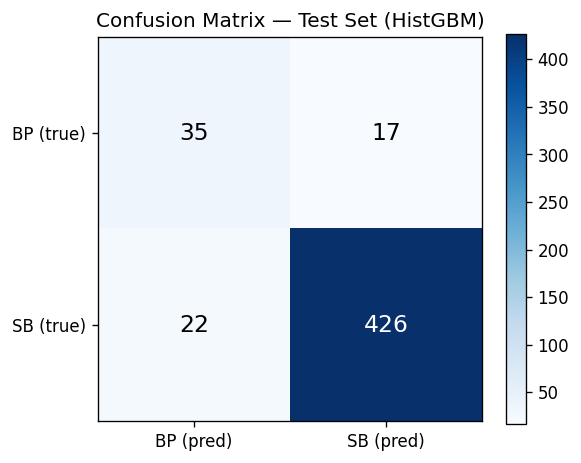

Saved confusion_matrix.png


In [162]:
# ── Confusion matrix heatmap ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_test, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['BP (pred)', 'SB (pred)'])
ax.set_yticklabels(['BP (true)', 'SB (true)'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_test[i,j]), ha='center', va='center', fontsize=14,
                color='white' if cm_test[i,j] > cm_test.max()*0.5 else 'black')
ax.set_title('Confusion Matrix — Test Set (HistGBM)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(ROOT / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved confusion_matrix.png')

In [163]:
# ── Misclassification samples ─────────────────────────────────────────────────

test_df = pd.DataFrame({'text': X_test, 'true': y_test, 'pred': y_pred_test})

# False negatives: substantive predicted as boilerplate (most costly)
fn = test_df[(test_df.true == 1) & (test_df.pred == 0)]
# False positives: boilerplate predicted as substantive
fp = test_df[(test_df.true == 0) & (test_df.pred == 1)]

print(f'False negatives (SB→BP): {len(fn)}')
print(f'False positives (BP→SB): {len(fp)}')

print('\n--- False negatives (substantive labelled as boilerplate) ---')
for _, row in fn.head(8).iterrows():
    print(f'  "{row.text[:120]}"')

print('\n--- False positives (boilerplate labelled as substantive) ---')
for _, row in fp.head(8).iterrows():
    print(f'  "{row.text[:120]}"')

False negatives (SB→BP): 22
False positives (BP→SB): 17

--- False negatives (substantive labelled as boilerplate) ---
  "And I am highly confident in our ability to get the remaining work done."
  "Now turning to the left side of the slide, where we show our financial results for the full FERC."
  "We're In a strong financial position, feel very good about the leadership team."
  "And then we're going to take a different approach."
  "I was lucky enough to be at Augusta earlier that week, and I couldn't help but relate Rory's experience to NIKE's recent"
  "Angela, who is our GM in Greater China, is now part of my SLT, Senior Leadership Team, and I look forward to working wit"
  "And we announced this morning that Jeff has been elevated to President of Fastenal."
  "The piece that Jeff just touched on, though, is on the e-commerce piece of it, things like website."

--- False positives (boilerplate labelled as substantive) ---
  "And so you see -- there's lots of puts and takes."
  "A

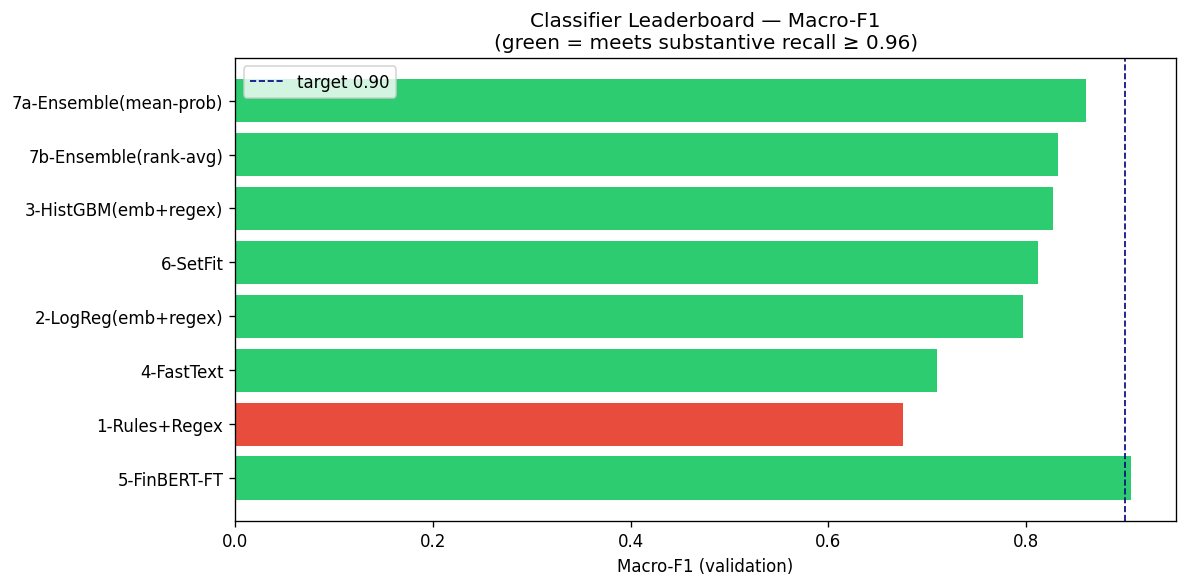

Saved leaderboard.png


In [164]:
# ── Final leaderboard plot ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if m else '#e74c3c' for m in lb_df['meets_floor']]
bars = ax.barh(lb_df['model'][::-1], lb_df['macro_f1'][::-1], color=colors[::-1])
ax.axvline(0.9, color='navy', linestyle='--', linewidth=1, label='target 0.90')
ax.set_xlabel('Macro-F1 (validation)')
ax.set_title('Classifier Leaderboard — Macro-F1\n(green = meets substantive recall ≥ 0.96)')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'leaderboard.png', dpi=150)
plt.show()
print('Saved leaderboard.png')